# **CARACTERIZACIÓN DE TODAS LAS SLOPE UNITS**

## DEJAMOS SOLO COLUMNAS NECESARIAS Y GUARDAMOS COMO UN NUEVO ARCHIVO GEOPACKAGE PARA SU POSTERIOR USO EN QGIS.

In [1]:
import geopandas as gpd


path_slope_units = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis.shp"

gdf = gpd.read_file(path_slope_units)

cols = ["index", "area", "cluster4", "zona", "n_mm", "geometry"]
gdf_slope_units = gdf.loc[:, cols].copy()

out_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales.gpkg"

layer_name = "slope_units"

gdf_slope_units.to_file(out_path, layer=layer_name, driver="GPKG")

## VAMOS CARACTERIZAR TODAS LAS SLOPE UNITS CON LAS VARIABLES

### **Geología**

In [1]:
import pandas as pd
import geopandas as gpd

path_SU_si = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"
path_geo   = "/home/oisanchezp/Thesis/data/metadata/geo.geojson"

SU_si = gpd.read_file(path_SU_si)
geo   = gpd.read_file(path_geo)

# 1) Asegurar que ambas capas están en el mismo CRS
#    (idealmente un CRS proyectado en metros, pero usamos el de las Slope Units como referencia)
if geo.crs != SU_si.crs:
    geo = geo.to_crs(SU_si.crs)

# 2) Definir columna ID de la Slope Unit
id_col = "index" if "index" in SU_si.columns else "index"
if id_col not in SU_si.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en SU_si para usar como ID de Slope Unit.")

# 3) Crear una capa de Slope Units únicas (una geometría por SU)
su_unique = SU_si[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()

# 4) Hacer overlay SU x Geología (intersección)
#    Nos quedamos sólo con 'Geologia' de la capa geo para no arrastrar basura
geo_min = geo[["Geologia", "geometry"]].copy()

su_geo_int = gpd.overlay(su_unique, geo_min, how="intersection")

# 5) Calcular área de intersección para cada combinación SU - Unidad geológica
su_geo_int["area_int"] = su_geo_int.geometry.area

# 6) Para cada Slope Unit, quedarnos con la unidad geológica que más área aporta
idx_max = su_geo_int.groupby(id_col)["area_int"].idxmax()

# su_geo_dom: una fila por Slope Unit, con la geología dominante
su_geo_dom = su_geo_int.loc[idx_max, [id_col, "Geologia"]].copy()
su_geo_dom = su_geo_dom.rename(columns={"Geologia": "geologia"})

# 7) Unir la geología dominante a TODAS las filas de SU_si (incluyendo eventos)
SU_si_geo = SU_si.merge(su_geo_dom, on=id_col, how="left")

# 8) (Opcional) guardar resultado
out_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"

layer_name = "slope_units"

SU_si_geo.to_file(out_path, layer=layer_name, driver="GPKG")

print("Listo ✅")

Listo ✅


### **Coberturas**

- Mapa de coberturas tomado de Monica 2021

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterstats import zonal_stats

path_SU_si = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"
path_cober  = "/home/oisanchezp/Thesis/data/metadata/Coberturas_Valle.tif"

SU_si = gpd.read_file(path_SU_si)

# 1) Asegurar mismo CRS entre Slope Units y raster
with rasterio.open(path_cober) as src:
    raster_crs   = src.crs
    raster_nodata = src.nodata

if SU_si.crs != raster_crs:
    SU_si = SU_si.to_crs(raster_crs)

# 2) Definir ID de Slope Unit
id_col = "index" if "index" in SU_si.columns else "index"
if id_col not in SU_si.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en SU_si para usar como ID de Slope Unit.")

# 3) Quedarnos con una geometría por Slope Unit (para no repetir trabajo)
su_unique = SU_si[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()
# 4) Zonal stats: clase de cobertura dominante (majority) dentro de cada Slope Unit
#    - stats=['majority'] -> devuelve el valor de píxel más frecuente
#    - all_touched=False -> solo píxeles cuyo centro cae dentro del polígono
#      (si quieres ser más laxo, puedes usar True)
zs = zonal_stats(
    su_unique,
    path_cober,
    stats=["majority"],
    nodata=raster_nodata,
    all_touched=False,
    geojson_out=False
)

# 5) Guardar el código de cobertura dominante en su_unique
su_unique["cov_code"] = [
    z["majority"] if z["majority"] is not None else np.nan
    for z in zs
]

# 6) Unir esa cobertura dominante a TODAS las filas de SU_si
SU_si_cov = SU_si.merge(
    su_unique[[id_col, "cov_code"]],
    on=id_col,
    how="left"
)

# 7) (Opcional) renombrar la columna a algo más explícito
SU_si_cov = SU_si_cov.rename(columns={"cov_code": "cobertura"})

out_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"

layer_name = "slope_units"

SU_si_cov.to_file(out_path, layer=layer_name, driver="GPKG")


/home/oisanchezp/geo_env/lib/python3.8/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


### **AGREGAMOS PENDIENTES Y ASPECTOS**

- Pendiente media de la Slope Unit
- Desviación estándar de la pendiente de la Slope Unit
- Aspecto medio de la Slope Unit
- Desviación estándar del aspecto de la Slope Unit

In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# Rutas
path_SU   = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"
dem_path  = "/home/oisanchezp/Thesis/data/metadata/dem_AMVA_5m.tif"

# 1) Leer Slope Units (con eventos)
SU = gpd.read_file(path_SU)

# Definir columna ID de Slope Unit
id_col = "index" if "index" in SU.columns else "index"
if id_col not in SU.columns:
    raise ValueError("No encuentro ni 'su_idx' ni 'index' en la capa de Slope Units.")

# 2) Leer DEM
with rasterio.open(dem_path) as src:
    dem = src.read(1, masked=True)    # masked array
    dem_transform = src.transform
    dem_crs = src.crs
    dem_nodata = src.nodata

# 3) Asegurar mismo CRS entre SU y DEM
if SU.crs != dem_crs:
    SU = SU.to_crs(dem_crs)

# 4) Calcular pendiente y aspecto a partir del DEM
#    Obtenemos tamaño de pixel en x e y (en unidades del CRS, idealmente metros)
xres = abs(dem_transform.a)
yres = abs(dem_transform.e)

# gradiente en y (filas) y x (columnas)
gy, gx = np.gradient(dem.filled(np.nan), yres, xres)

# Pendiente (rad) y luego en grados
slope_rad = np.arctan(np.sqrt(gx**2 + gy**2))
slope_deg = np.degrees(slope_rad)

# Aspecto:
# convención típica: 0° = norte, aumenta en el sentido de las agujas del reloj
aspect_rad = np.arctan2(-gx, gy)  # ojo con el signo para que 0° sea norte
aspect_deg = np.degrees(aspect_rad)
aspect_deg = np.where(aspect_deg < 0, 360.0 + aspect_deg, aspect_deg)

# Aplicar máscara de DEM también a slope y aspect
mask = dem.mask | np.isnan(dem.filled(np.nan))
slope_deg = np.where(mask, np.nan, slope_deg)
aspect_deg = np.where(mask, np.nan, aspect_deg)

# 5) Crear Slope Units únicas (una geometría por SU)
su_unique = SU[[id_col, "geometry"]].drop_duplicates(subset=id_col).copy()

# 6) Zonal stats para pendiente: media y desviación estándar
zs_slope = zonal_stats(
    su_unique,
    slope_deg,
    affine=dem_transform,
    stats=["mean", "std"],
    nodata=np.nan,
    all_touched=False,
    geojson_out=False
)

su_unique["slope_mean"] = [z["mean"] for z in zs_slope]
su_unique["slope_std"]  = [z["std"]  for z in zs_slope]

# 7) Zonal stats para aspecto: media y desviación estándar (lineal)
# Nota: esto trata el aspecto como variable lineal; si luego quieres
# algo más fino (estadística circular), lo podemos refinar.
zs_aspect = zonal_stats(
    su_unique,
    aspect_deg,
    affine=dem_transform,
    stats=["mean", "std"],
    nodata=np.nan,
    all_touched=False,
    geojson_out=False
)

su_unique["aspect_mean"] = [z["mean"] for z in zs_aspect]
su_unique["aspect_std"]  = [z["std"]  for z in zs_aspect]

# 8) Unir estas estadísticas a TODAS las filas de la capa original (con eventos)
SU_stats = SU.merge(
    su_unique[[id_col, "slope_mean", "slope_std", "aspect_mean", "aspect_std"]],
    on=id_col,
    how="left"
)

# 9) Guardar resultado
out_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"

layer_name = "slope_units"

SU_stats.to_file(out_path, layer=layer_name, driver="GPKG")

print("Listo ✅")
print(f"Guardado en: {out_path}")


Listo ✅
Guardado en: /home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg


### **AGREGAMOS FECHAS A LAS SLOPE UNITS QUE TIENE DESLIZAMIENTOS**

In [5]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np

# ============================================================
# 0) RUTAS
# ============================================================
slope_units_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_iniciales_2.gpkg"
su_layer         = "slope_units"
inventario_csv   = "../../data/processed/inventario_si_20251109.csv"

out_gpkg         = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
out_layer        = "slope_units_full"   # <-- UN SOLO LAYER

os.makedirs(os.path.dirname(out_gpkg), exist_ok=True)

# ============================================================
# 1) LEER SLOPE UNITS
# ============================================================
su = gpd.read_file(slope_units_gpkg, layer=su_layer)

su_id_col = "index"
if su_id_col not in su.columns:
    raise ValueError(f"No encuentro '{su_id_col}' en Slope Units.")

if su.crs is None:
    raise ValueError("Slope Units sin CRS. Asigna CRS antes de continuar.")

# ============================================================
# 2) LEER INVENTARIO y GARANTIZAR COLUMNAS ESPERADAS
# ============================================================
inv = pd.read_csv(inventario_csv)

# columnas esperadas del inventario (todas deben existir en salida)
base_cols = [
    "fecha_hora_evento","incertidumbre_fecha","latitud","longitud","incertidumbre_ubicacion",
    "tipo_movimiento_masa","municipio","corregimiento","vereda_barrio","Codigo","si_no"
]
rain_cols = [f"{i}d" for i in range(1, 98)]  # 1d..97d
expected_cols = base_cols + rain_cols

# crear las que falten en el CSV (quedan NaN)
for c in expected_cols:
    if c not in inv.columns:
        inv[c] = np.nan

# limpiar coords
inv["latitud"]  = pd.to_numeric(inv["latitud"], errors="coerce")
inv["longitud"] = pd.to_numeric(inv["longitud"], errors="coerce")
inv = inv.dropna(subset=["latitud", "longitud"]).copy()

# parse fecha
inv["fecha_hora_evento"] = pd.to_datetime(inv["fecha_hora_evento"], errors="coerce")

# (opcional) deduplicar SOLO duplicados accidentales (misma fecha + misma ubicación)
inv = inv.drop_duplicates(subset=["fecha_hora_evento","latitud","longitud"])

# GeoDataFrame puntos (asumo lat/lon en EPSG:4326)
inv_gdf = gpd.GeoDataFrame(
    inv,
    geometry=gpd.points_from_xy(inv["longitud"], inv["latitud"]),
    crs="EPSG:4326"
).to_crs(su.crs)

# ============================================================
# 3) CRUCE ESPACIAL (puntos dentro/intersecta SU)
# ============================================================
su_min = su[[su_id_col, "geometry"]].copy()

join = gpd.sjoin(
    inv_gdf[expected_cols + ["geometry"]],
    su_min,
    how="inner",
    predicate="intersects"
)

# llave robusta de evento:
# - si hay fecha -> la usa
# - si no hay fecha -> usa el índice del punto para no colapsar NaT
join["evento_key"] = np.where(
    join["fecha_hora_evento"].notna(),
    join["fecha_hora_evento"].astype("datetime64[ns]").astype(str),
    "NA_" + join.index.astype(str)
)

# ============================================================
# 4) HACER 1 FILA POR (SU, evento_key)  => duplicación por fecha/evento
# ============================================================
def first_notnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def concat_unique(s):
    vals = pd.unique(s.dropna())
    return "; ".join(map(str, vals)) if len(vals) else np.nan

# agregación: la mayoría "primero no nulo"
agg = {c: first_notnull for c in expected_cols}

# si en mismo (SU, evento) llega más de un valor, concatenamos
for c in ["Codigo","municipio","corregimiento","vereda_barrio","tipo_movimiento_masa"]:
    agg[c] = concat_unique

su_eventos_df = (
    join.groupby([su_id_col, "evento_key"])
        .agg(agg)
        .reset_index()
)

# ============================================================
# 5) UN SOLO LAYER: left-merge para conservar TODAS las SU
#     - SU sin eventos => una fila con NaN en columnas heredadas
#     - SU con k eventos => k filas duplicadas
# ============================================================
su_full = su.merge(su_eventos_df, on=su_id_col, how="left")

# mm = número de eventos por SU (conteo de evento_key)
mm_by_su = su_eventos_df.groupby(su_id_col)["evento_key"].nunique().rename("mm")

su_full["mm"] = su_full[su_id_col].map(mm_by_su).fillna(0).astype(int)
su_full["si_no"] = (su_full["mm"] > 0).astype(int)

su_full = gpd.GeoDataFrame(su_full, geometry="geometry", crs=su.crs)

# ============================================================
# 6) GUARDAR (UN SOLO LAYER)
# ============================================================
su_full.to_file(out_gpkg, layer=out_layer, driver="GPKG")

print("Listo ✅")
print(f"- Salida: {out_gpkg} | layer={out_layer}")
print(f"- Filas: {len(su_full)} (incluye duplicadas por evento)")
print(f"- SU únicas: {su[su_id_col].nunique()}")
print(f"- SU sin eventos: {(su_full['mm']==0).sum()} filas (debería ser = #SU sin eventos)")


Listo ✅
- Salida: /home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg | layer=slope_units_full
- Filas: 57586 (incluye duplicadas por evento)
- SU únicas: 57524
- SU sin eventos: 57142 filas (debería ser = #SU sin eventos)


### **AGREGAMOS COLUMNA MES Y COLUMNA ENSO DEPENDIENDO DEL DÍA**



#### **MES Y DÍA DEL AÑO DOY**

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

# =========================
# RUTAS
# =========================
gpkg_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_full"
layer_out = "slope_units_full"  # sobrescribe el mismo layer (si prefieres otro, cambia el nombre)

# =========================
# 1) ABRIR
# =========================
gdf = gpd.read_file(gpkg_path, layer=layer_in)

# =========================
# 2) CREAR COLUMNAS Mes y DoY (solo si_no==1)
# =========================
# asegurar datetime
gdf["fecha_hora_evento"] = pd.to_datetime(gdf["fecha_hora_evento"], errors="coerce")

# inicializar con NaN para todos
gdf["Mes"] = np.nan
gdf["DoY"] = np.nan

mask = (gdf["si_no"] == 1) & (gdf["fecha_hora_evento"].notna())

gdf.loc[mask, "Mes"] = gdf.loc[mask, "fecha_hora_evento"].dt.month.astype(int)
gdf.loc[mask, "DoY"] = gdf.loc[mask, "fecha_hora_evento"].dt.dayofyear.astype(int)

# (opcional) usar enteros nulos (pandas nullable Int64)
gdf["Mes"] = gdf["Mes"].astype("Int64")
gdf["DoY"] = gdf["DoY"].astype("Int64")

# =========================
# 3) GUARDAR
# =========================
# Nota: en algunos setups, para sobrescribir layer conviene borrar y re-escribir.
# GeoPandas suele sobreescribir el layer si existe, pero si te falla, dime el error y lo ajustamos.
gdf.to_file(gpkg_path, layer=layer_out, driver="GPKG")

print("Listo ✅")
print(f"Guardado en: {gpkg_path} | layer={layer_out}")
print("Ejemplo (primeras 5 filas con si_no=1):")
print(gdf.loc[gdf["si_no"]==1, ["fecha_hora_evento","Mes","DoY"]].head())


Listo ✅
Guardado en: /home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg | layer=slope_units_full
Ejemplo (primeras 5 filas con si_no=1):
       fecha_hora_evento  Mes  DoY
1202 2024-06-09 12:00:00    6  161
1229 2022-05-05 22:30:00    5  125
1237 2021-06-01 19:31:00    6  152
1260 2021-06-26 00:00:00    6  177
1311 2021-03-23 00:00:00    3   82


#### **ENSO**

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np

# =========================
# RUTAS
# =========================
gpkg_path = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_full"
layer_out = "slope_units_full"  # sobrescribe el mismo layer (si prefieres otro, cambia el nombre)

# =========================
# 1) ABRIR
# =========================
gdf = gpd.read_file(gpkg_path, layer=layer_in)

# Ruta de la tabla que tú vas a construir a partir de la imagen
oni_csv = "/home/oisanchezp/Thesis/data/metadata/ENSO.csv"

# 1) Leer tabla trimestral
oni_tri = pd.read_csv(oni_csv)

# 2) Pasar de formato ancho (DJF, JFM, ...) a largo
oni_long = oni_tri.melt(
    id_vars="Year",
    var_name="Season",
    value_name="ONI"
)

# 3) Mapeo de mes -> Season (según tu interpretación de la tabla)
month_to_season = {
    1: "DJF",
    2: "JFM",
    3: "FMA",
    4: "MAM",
    5: "AMJ",
    6: "MJJ",
    7: "JJA",
    8: "JAS",
    9: "ASO",
    10: "SON",
    11: "OND",
    12: "NDJ",
}

# 4) Crear un rango diario desde 2010-01-01 hasta 2025-12-31
dates = pd.date_range("2010-01-01", "2025-12-31", freq="D")
df_days = pd.DataFrame({"date": dates})
df_days["Year"] = df_days["date"].dt.year
df_days["Month"] = df_days["date"].dt.month

# 5) Añadir la Season que corresponde a cada mes
df_days["Season"] = df_days["Month"].map(month_to_season)

# 6) Unir con la tabla de ONI trimestral (Year + Season)
df_days = df_days.merge(
    oni_long,
    on=["Year", "Season"],
    how="left"
)

# 7) Clasificar ENSO a partir del valor de ONI
#    Umbrales típicos:
#    ONI >=  0.5 -> El Niño (rojo)
#    ONI <= -0.5 -> La Niña (azul)
#    |ONI| < 0.5 -> Neutro (negro)

def clasificar_enso(oni):
    if pd.isna(oni):
        return np.nan
    if oni >= 0.5:
        return "El Niño"
    elif oni <= -0.5:
        return "La Niña"
    else:
        return "Neutro"

df_days["ENSO"] = df_days["ONI"].apply(clasificar_enso)

# --- Excepciones manuales donde, a pesar del ONI, se declaró Neutro ---

exc_neutro = (
    # Noviembre y diciembre 2019
    ((df_days["Year"] == 2019) & df_days["Month"].isin([11, 12])) |
    # Enero y febrero 2020
    ((df_days["Year"] == 2020) & df_days["Month"].isin([1, 2])) |
    # Diciembre 2024
    ((df_days["Year"] == 2024) & (df_days["Month"] == 12)) |
    # Enero y septiembre 2025
    ((df_days["Year"] == 2025) & df_days["Month"].isin([1, 9])) |
    # Febrero 2014
    ((df_days["Year"] == 2014) & (df_days["Month"] == 2))
)

df_days.loc[exc_neutro, "ENSO"] = "Neutro"

# 8) (Opcional) ordenar columnas y guardar
df_days = df_days[["date", "Year", "Month", "ONI", "ENSO"]]

out_csv = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"
df_days.to_csv(out_csv, index=False)

print("Listo ✅")
print(f"Archivo diario guardado en: {out_csv}")
print(df_days.head())


Listo ✅
Archivo diario guardado en: /home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv
        date  Year  Month  ONI     ENSO
0 2010-01-01  2010      1  1.5  El Niño
1 2010-01-02  2010      1  1.5  El Niño
2 2010-01-03  2010      1  1.5  El Niño
3 2010-01-04  2010      1  1.5  El Niño
4 2010-01-05  2010      1  1.5  El Niño


In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

# =========================
# RUTAS
# =========================
path_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_full"

path_oni  = "/home/oisanchezp/Thesis/data/metadata/oni_diario_2010_2025.csv"

out_gpkg  = path_gpkg
layer_out = "slope_units_full"   # sobrescribe el mismo layer (si prefieres otro, cambia)

# =========================
# 1) LEER Slope Units (1 solo layer)
# =========================
SU = gpd.read_file(path_gpkg, layer=layer_in)

# asegurar datetime
SU["fecha_hora_evento"] = pd.to_datetime(SU["fecha_hora_evento"], errors="coerce")

# crear date (solo fecha)
SU["date"] = SU["fecha_hora_evento"].dt.normalize()

# =========================
# 2) LEER ONI/ENSO diario
# =========================
oni = pd.read_csv(path_oni)
oni["date"] = pd.to_datetime(oni["date"], errors="coerce")

# (opcional) por si hay duplicados en oni
oni = oni.drop_duplicates(subset=["date"])

# =========================
# 3) ASIGNAR ONI/ENSO SOLO a si_no==1
# =========================
# inicializar columnas
if "ONI" not in SU.columns:
    SU["ONI"] = np.nan
if "ENSO" not in SU.columns:
    SU["ENSO"] = np.nan

mask = (SU["si_no"] == 1) & (SU["date"].notna())

tmp = SU.loc[mask, [*SU.columns]].merge(
    oni[["date", "ONI", "ENSO"]],
    on="date",
    how="left",
    suffixes=("", "_oni")
)

# asignar de vuelta (manteniendo NaN para si_no==0)
SU.loc[mask, "ONI"]  = tmp["ONI_oni"].to_numpy()
SU.loc[mask, "ENSO"] = tmp["ENSO_oni"].to_numpy()

# =========================
# 4) GUARDAR
# =========================
SU = gpd.GeoDataFrame(SU, geometry="geometry", crs=SU.crs)
SU.to_file(out_gpkg, layer=layer_out, driver="GPKG")

print("Listo ✅")
print(f"Guardado en: {out_gpkg} | layer={layer_out}")
print(SU.loc[SU["si_no"]==1, ["fecha_hora_evento","date","ONI","ENSO"]].head())


Listo ✅
Guardado en: /home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg | layer=slope_units_full
       fecha_hora_evento       date  ONI     ENSO
1202 2024-06-09 12:00:00 2024-06-09  0.2   Neutro
1229 2022-05-05 22:30:00 2022-05-05 -1.0  La Niña
1237 2021-06-01 19:31:00 2021-06-01 -0.4   Neutro
1260 2021-06-26 00:00:00 2021-06-26 -0.4   Neutro
1311 2021-03-23 00:00:00 2021-03-23 -0.8  La Niña


#### **GRAFICAMOS LAS METRICAS PARA VER CUAL ES LA MEJOR COMBINACIÓN DE DÍAS**

In [2]:
import pandas as pd
import numpy as np
import re

path = "/home/oisanchezp/Thesis/data/processed/GAM_MC_summary_T1-7_P8-90.csv"  # ajusta si cambia
raw = pd.read_csv(path)

# La fila 0 trae los labels mean/median/std
stat_row = raw.iloc[0].to_dict()

df = raw.iloc[1:].copy()
df[["T_days", "P_days"]] = df[["T_days", "P_days"]].astype(int)

# convertir a numérico todo lo demás
for c in df.columns[2:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# pasar a formato largo: (T, P, metric, stat, value)
parts = []
for c in df.columns[2:]:
    metric = re.sub(r"\.\d+$", "", c)      # auc.1 -> auc
    stat   = stat_row.get(c, "")           # mean/median/std
    tmp = df[["T_days", "P_days", c]].rename(columns={c: "value"})
    tmp["metric"] = metric
    tmp["stat"]   = stat
    parts.append(tmp)

long = pd.concat(parts, ignore_index=True)


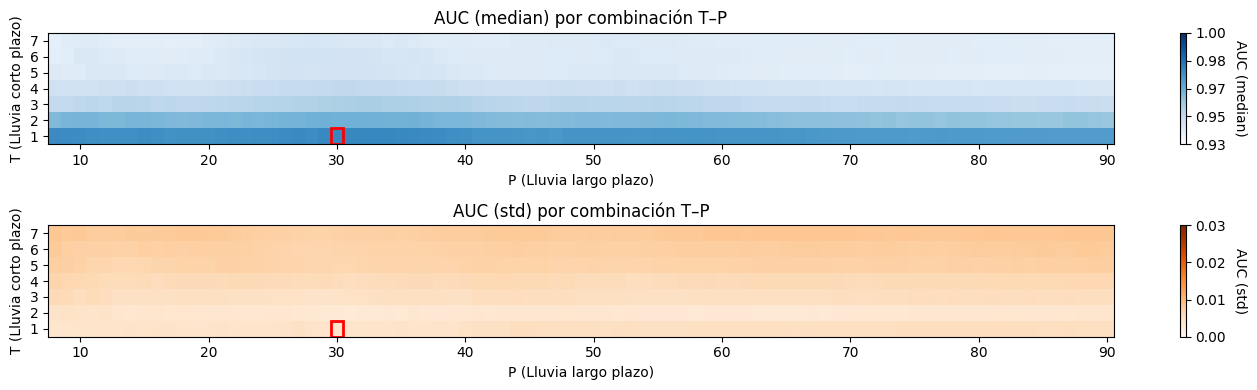

Mejor (por mean): T= 1 P= 30 AUC= 0.9766434583472616


In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

metric = "auc"
stat   = "median"

mat = (long.query("metric==@metric and stat==@stat")
            .pivot(index="T_days", columns="P_days", values="value")
            .sort_index()
            .sort_index(axis=1))

T_vals = mat.index.to_list()
P_vals = mat.columns.to_list()

mean_mat = mat.to_numpy()

# mejor celda (max mean)
i_best, j_best = np.unravel_index(np.nanargmax(mean_mat), mean_mat.shape)

fig, axes = plt.subplots(2,1, figsize=(14,4), sharey=True)

im = axes[0].imshow(mean_mat, 
                    origin="lower", 
                    aspect="auto", 
                    cmap="Blues",
                    vmin=0.93,
                    vmax=1.00)

cbar0 = plt.colorbar(im, ax=axes[0], label=f"{metric.upper()} ({stat})")
ticks_mean = np.linspace(0.93, 1.00, 5)
cbar0.set_ticks(ticks_mean)
cbar0.set_ticklabels([f"{t:.2f}" for t in ticks_mean])
cbar0.set_label(f"{metric.upper()} ({stat})", rotation=270, labelpad=15)

# ticks P cada 10
xticks_idx = [j for j,p in enumerate(P_vals) if p % 10 == 0]
axes[0].set_xticks(xticks_idx)
axes[0].set_xticklabels([P_vals[j] for j in xticks_idx])
axes[0].set_yticks(np.arange(len(T_vals)))
axes[0].set_yticklabels(T_vals)

axes[0].set_xlabel("P (Lluvia largo plazo)")
axes[0].set_ylabel("T (Lluvia corto plazo)")
axes[0].set_title(f"{metric.upper()} ({stat}) por combinación T–P")

# cuadrito a la mejor combinación
axes[0].add_patch(Rectangle((j_best-0.5, i_best-0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))


#--- PANEL 2: DESVIACIÓN ESTÁNDAR ---#
stat = "std"
mat_std = (long.query("metric==@metric and stat==@stat")
                .pivot(index="T_days", columns="P_days", values="value")
                .sort_index()
                .sort_index(axis=1))
std_mat = mat_std.to_numpy()
im2 = axes[1].imshow(std_mat, 
                     origin="lower", 
                     aspect="auto", 
                     cmap="Oranges",
                     vmin=0.0,
                     vmax=0.03)

cbar1 = plt.colorbar(im2, ax=axes[1], label=f"{metric.upper()} ({stat})")
ticks_std = np.linspace(0.0, 0.03, 4)
cbar1.set_ticks(ticks_std)
cbar1.set_ticklabels([f"{t:.2f}" for t in ticks_std])
cbar1.set_label(f"{metric.upper()} ({stat})", rotation=270, labelpad=15)

# ticks P cada 10
axes[1].set_xticks(xticks_idx)
axes[1].set_xticklabels([P_vals[j] for j in xticks_idx])
axes[1].set_yticks(np.arange(len(T_vals)))
axes[1].set_yticklabels(T_vals)
axes[1].set_xlabel("P (Lluvia largo plazo)")
axes[1].set_ylabel("T (Lluvia corto plazo)")
axes[1].set_title(f"{metric.upper()} ({stat}) por combinación T–P")


#Cuadro en la mejor combinación
axes[1].add_patch(Rectangle((j_best-0.5, i_best-0.5), 1, 1, fill=False, edgecolor="red", linewidth=2))



plt.tight_layout()
plt.show()

print("Mejor (por mean):", "T=", T_vals[i_best], "P=", P_vals[j_best], "AUC=", mean_mat[i_best, j_best])


In [4]:
print(sorted(long["metric"].unique()))

['ap', 'auc', 'bacc', 'f1', 'hk', 'pofd', 'precision', 'recall']


In [8]:
long['stat'].unique()

array(['mean', 'median', 'std'], dtype=object)

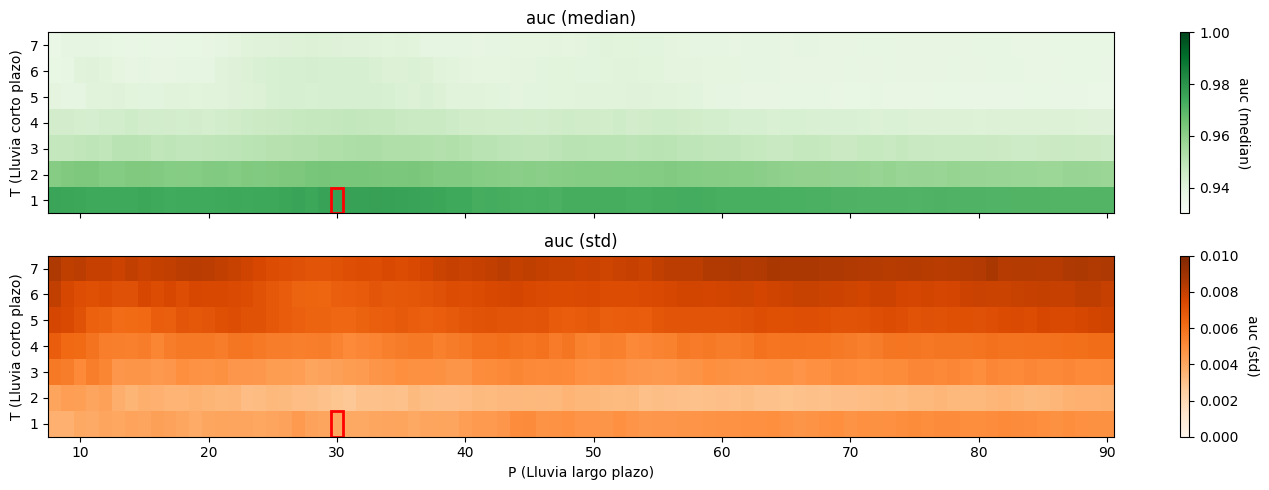

Mejor combinación para auc (max median): T=1, P=30, median=0.9766, std=0.0041


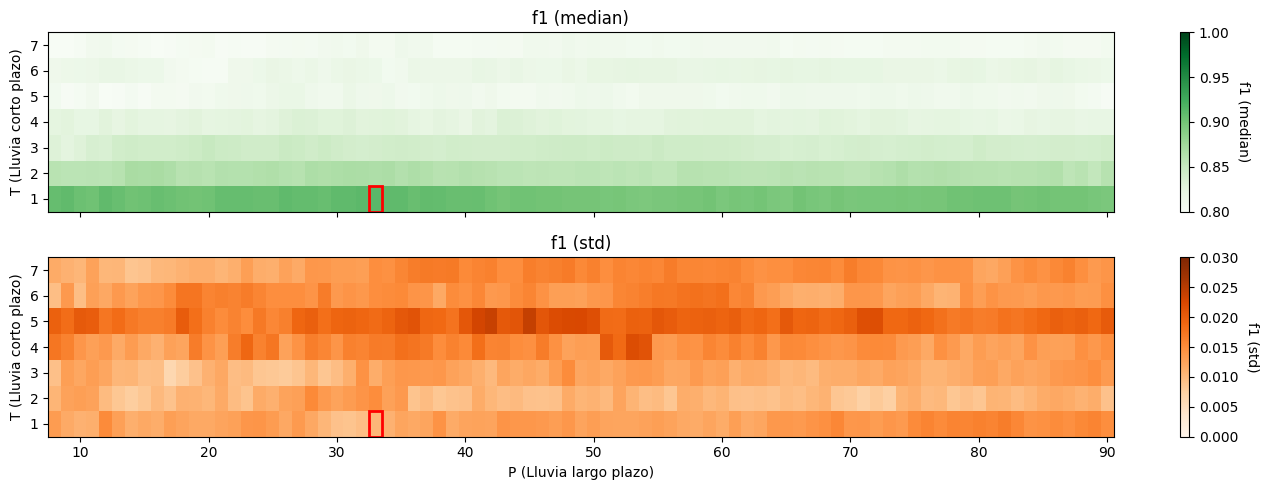

Mejor combinación para f1 (max median): T=1, P=33, median=0.9118, std=0.0104


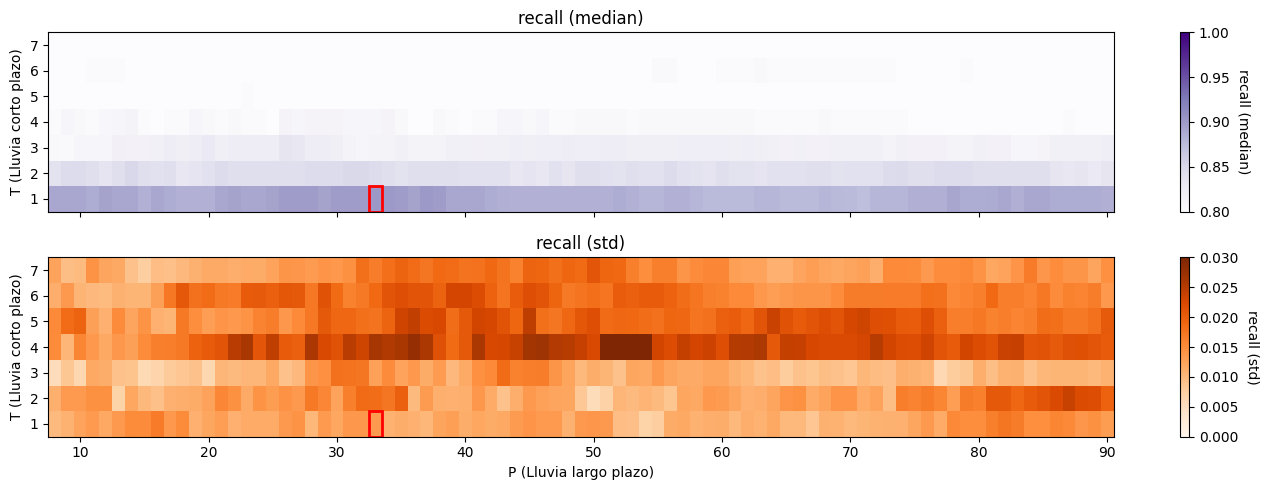

Mejor combinación para recall (max median): T=1, P=33, median=0.9015, std=0.0134


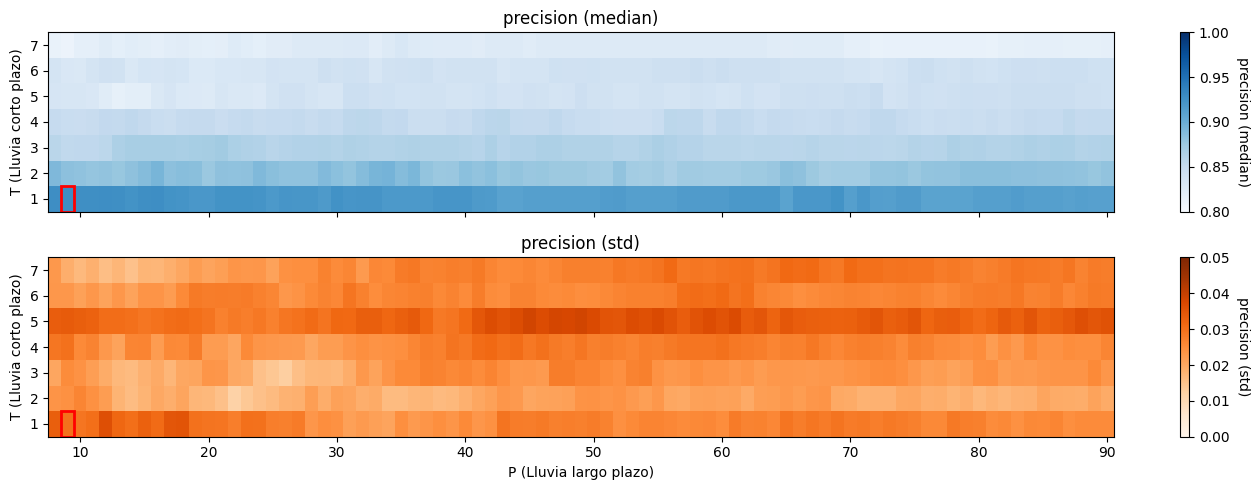

Mejor combinación para precision (max median): T=1, P=9, median=0.9278, std=0.0298


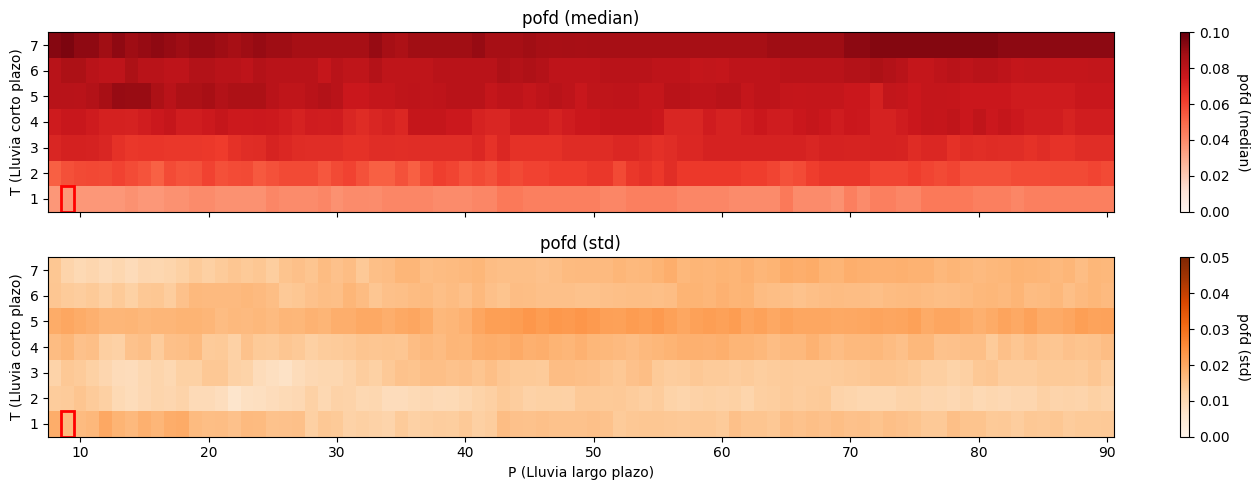

Mejor combinación para pofd (max median): T=1, P=9, median=0.0356, std=0.0167


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_metric_heatmaps(long, metric,
                         stat_main="median",
                         vmin_main=None, vmax_main=None, cmap_main="Blues",
                         vmin_std=None,  vmax_std=None,  cmap_std="Oranges",
                         xtick_step=10, figsize=(14, 5), title_prefix="",
                         mode="max"):
    
    # --- matriz principal ---
    mat = (long.query("metric==@metric and stat==@stat_main")
              .pivot(index="T_days", columns="P_days", values="value")
              .sort_index()
              .sort_index(axis=1))
    
    T_vals = mat.index.to_list()
    P_vals = mat.columns.to_list()
    main_mat = mat.to_numpy()

    def best_idx(mat, mode="max"):
        if mode == "max":
            return np.unravel_index(np.nanargmax(mat), mat.shape)
        else:
            return np.unravel_index(np.nanargmin(mat), mat.shape)
        
    # mejor celda (max)
    i_best, j_best = best_idx(main_mat, mode)


    # xticks cada 'xtick_step' (para P=10,20,...)
    xticks_idx = [j for j, p in enumerate(P_vals) if p % xtick_step == 0]

    # --- matriz std ---
    stat_std = "std"
    mat_std = (long.query("metric==@metric and stat==@stat_std")
                  .pivot(index="T_days", columns="P_days", values="value")
                  .reindex(index=mat.index, columns=mat.columns))  # asegurar mismo orden
    std_mat = mat_std.to_numpy()

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)

    # PANEL 1
    im0 = axes[0].imshow(main_mat, origin="lower", aspect="auto",
                         cmap=cmap_main, vmin=vmin_main, vmax=vmax_main)
    cbar0 = plt.colorbar(im0, ax=axes[0])
    cbar0.set_label(f"{metric} ({stat_main})", rotation=270, labelpad=15)

    axes[0].set_xticks(xticks_idx)
    axes[0].set_xticklabels([P_vals[j] for j in xticks_idx])
    axes[0].set_yticks(np.arange(len(T_vals)))
    axes[0].set_yticklabels(T_vals)
    axes[0].set_ylabel("T (Lluvia corto plazo)")
    axes[0].set_title(f"{title_prefix}{metric} ({stat_main})")

    axes[0].add_patch(Rectangle((j_best-0.5, i_best-0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2))

    # PANEL 2
    im1 = axes[1].imshow(std_mat, origin="lower", aspect="auto",
                         cmap=cmap_std, vmin=vmin_std, vmax=vmax_std)
    cbar1 = plt.colorbar(im1, ax=axes[1])
    cbar1.set_label(f"{metric} (std)", rotation=270, labelpad=15)

    axes[1].set_xticks(xticks_idx)
    axes[1].set_xticklabels([P_vals[j] for j in xticks_idx])
    axes[1].set_yticks(np.arange(len(T_vals)))
    axes[1].set_yticklabels(T_vals)

    axes[1].set_xlabel("P (Lluvia largo plazo)")
    axes[1].set_ylabel("T (Lluvia corto plazo)")
    axes[1].set_title(f"{title_prefix}{metric} (std)")

    axes[1].add_patch(Rectangle((j_best-0.5, i_best-0.5), 1, 1,
                                fill=False, edgecolor="red", linewidth=2))

    plt.tight_layout()
    plt.show()

    print(f"Mejor combinación para {metric} (max {stat_main}): T={T_vals[i_best]}, P={P_vals[j_best]}, "
          f"{stat_main}={main_mat[i_best, j_best]:.4f}, std={std_mat[i_best, j_best]:.4f}")



plot_metric_heatmaps(long, "auc",      vmin_main=0.93, vmax_main=1.0, vmin_std=0.0, vmax_std=0.01, cmap_main="Greens")
plot_metric_heatmaps(long, "f1",      vmin_main=0.8, vmax_main=1.0, vmin_std=0.0, vmax_std=0.03, cmap_main="Greens")
plot_metric_heatmaps(long, "recall",  vmin_main=0.8, vmax_main=1.0, vmin_std=0.0, vmax_std=0.03, cmap_main="Purples")
plot_metric_heatmaps(long, "precision",vmin_main=0.8, vmax_main=1.0, vmin_std=0.0, vmax_std=0.05, cmap_main="Blues")
plot_metric_heatmaps(long, "pofd",    vmin_main=0.0, vmax_main=0.1, vmin_std=0.0, vmax_std=0.05, cmap_main="Reds",
                     title_prefix="", stat_main="median", mode="min")




#### **RESULTADOS MONTECARLO EVALUANDO LOS 3 MODELOS**

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 0) CARGAR DATOS
# =========================
path = "/home/oisanchezp/Thesis/data/processed/resultados_paqueteb_3modelos_T1_P33_MC5.csv"  # <-- ajusta si es otro
df = pd.read_csv(path)

# (por si vienen con mayúsculas raras o espacios)
df.columns = [c.strip() for c in df.columns]

# métricas de interés
metrics = ["auc", "f1", "recall", "precision", "pofd"]
count_cols = ["tp", "tn", "fp", "fn"]

# =========================
# 1) TABLA RESUMEN (mean, median, sd, min, max)
# =========================
resumen = (
    df.groupby("modelo")[metrics]
      .agg(["mean", "median", "std", "min", "max"])
)

# aplanar columnas para que quede bonito
resumen.columns = [f"{m}_{stat}" for (m, stat) in resumen.columns]
resumen = resumen.reset_index()

print("\n=== RESUMEN MÉTRICAS (por modelo) ===")
print(resumen.to_string(index=False))

# # si quieres guardarla:
# out_resumen = "/home/oisanchezp/Thesis/data/processed/resumen_metricas_por_modelo.csv"
# resumen.to_csv(out_resumen, index=False)
# print(f"\nGuardado resumen en: {out_resumen}")


=== RESUMEN MÉTRICAS (por modelo) ===
      modelo  auc_mean  auc_median  auc_std  auc_min  auc_max  f1_mean  f1_median   f1_std   f1_min   f1_max  recall_mean  recall_median  recall_std  recall_min  recall_max  precision_mean  precision_median  precision_std  precision_min  precision_max  pofd_mean  pofd_median  pofd_std  pofd_min  pofd_max
         GAM  0.953844    0.953489 0.007135 0.940164 0.969286 0.870158   0.866664 0.015871 0.825532 0.913242     0.848621       0.844828    0.014795    0.810345    0.879310        0.893479          0.893805       0.029768       0.815126       0.970874   0.050290     0.050105  0.015794  0.012987  0.093617
       Logit  0.951748    0.951229 0.007551 0.937065 0.965373 0.861724   0.863166 0.018978 0.807843 0.903509     0.894310       0.896552    0.009509    0.870690    0.913793        0.832185          0.837398       0.034704       0.741007       0.919643   0.089698     0.085106  0.022691  0.038136  0.153191
RandomForest  0.960564    0.960019 0.006949

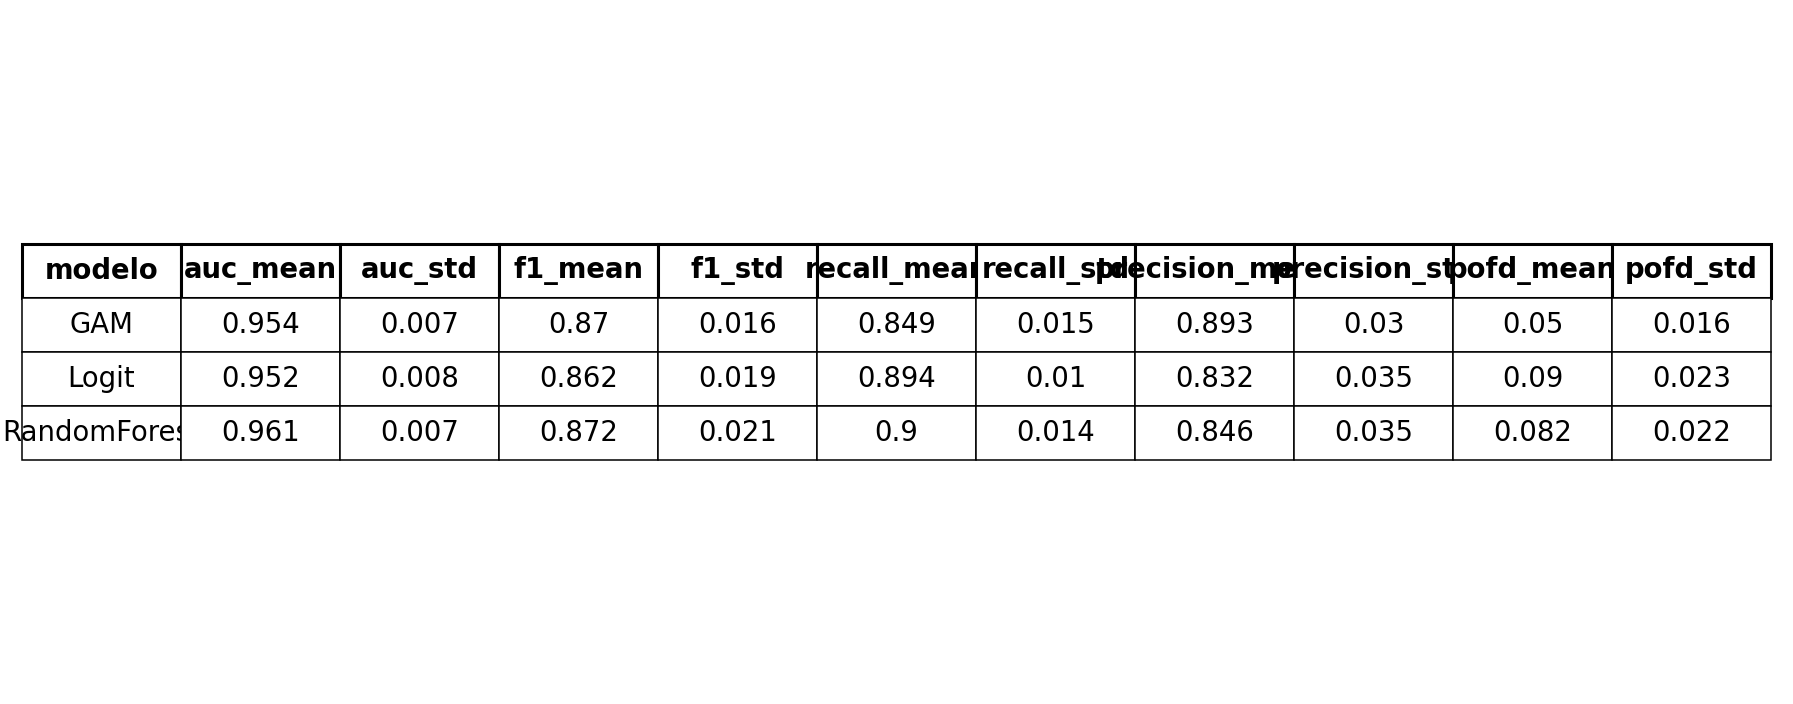

      modelo  auc_mean  auc_std  f1_mean   f1_std  recall_mean  recall_std  precision_mean  precision_std  pofd_mean  pofd_std
         GAM  0.953844 0.007135 0.870158 0.015871     0.848621    0.014795        0.893479       0.029768   0.050290  0.015794
       Logit  0.951748 0.007551 0.861724 0.018978     0.894310    0.009509        0.832185       0.034704   0.089698  0.022691
RandomForest  0.960564 0.006949 0.871714 0.020650     0.900000    0.014256        0.845850       0.034648   0.081527  0.021631


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

#out_fig_dir = "/home/oisanchezp/Thesis/figuras"
#os.makedirs(out_fig_dir, exist_ok=True)

# métricas que quieres
metrics = ["auc", "f1", "recall", "precision", "pofd"]

# 1) resumen solo mean y std
resumen_ms = (
    df.groupby("modelo")[metrics]
      .agg(["mean", "std"])
)

# aplanar nombres: auc_mean, auc_std, ...
resumen_ms.columns = [f"{m}_{stat}" for (m, stat) in resumen_ms.columns]
resumen_ms = resumen_ms.reset_index()

# 2) (opcional) redondear
res_img = resumen_ms.copy()
num_cols = res_img.columns.drop("modelo")
res_img[num_cols] = res_img[num_cols].astype(float).round(3)

# 3) tabla como imagen (más compacta)
fig_w = max(8, 0.75 * len(res_img.columns))
fig_h = 1.2 + 0.7 * len(res_img)   # crece con #modelos (pocas filas)
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=220)
ax.axis("off")

tbl = ax.table(
    cellText=res_img.values,
    colLabels=res_img.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.25)

# encabezado en negrita
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.0)
    else:
        cell.set_linewidth(0.5)

#out_png = os.path.join(out_fig_dir, "tabla_resumen_mean_std.png")
plt.tight_layout()
#plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()

print(resumen_ms.to_string(index=False))
#print(f"Guardada en: {out_png}")



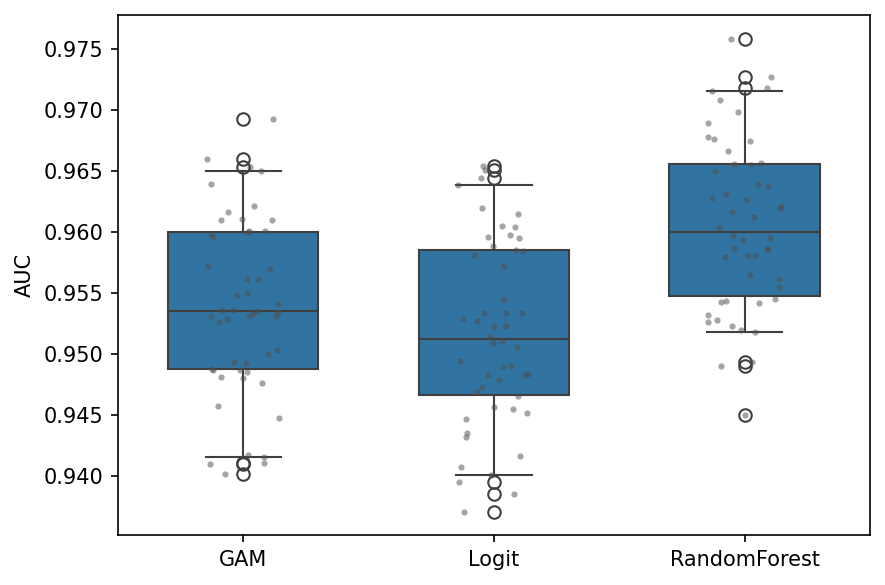

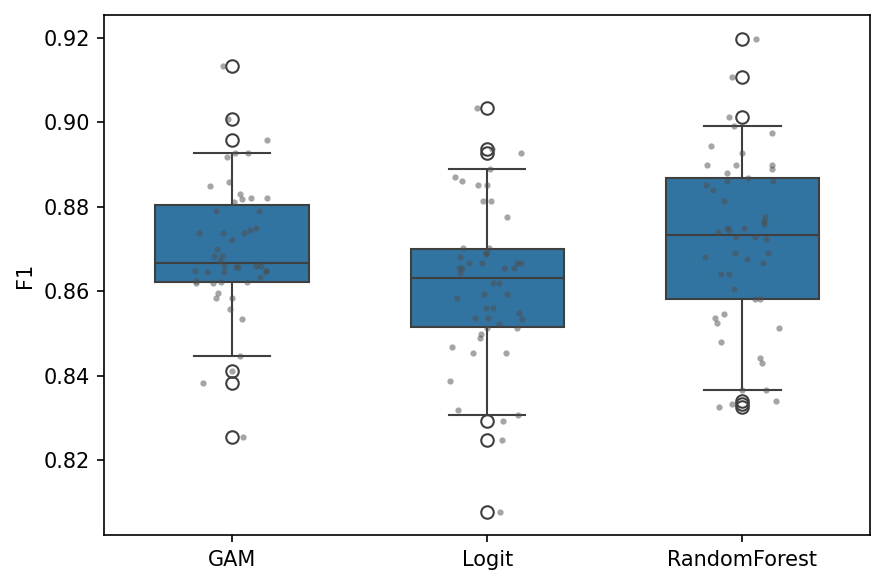

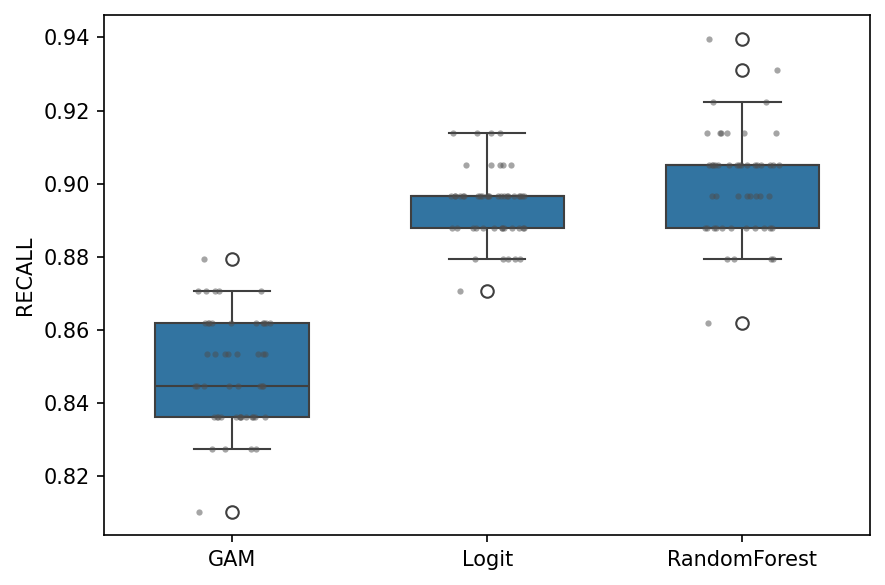

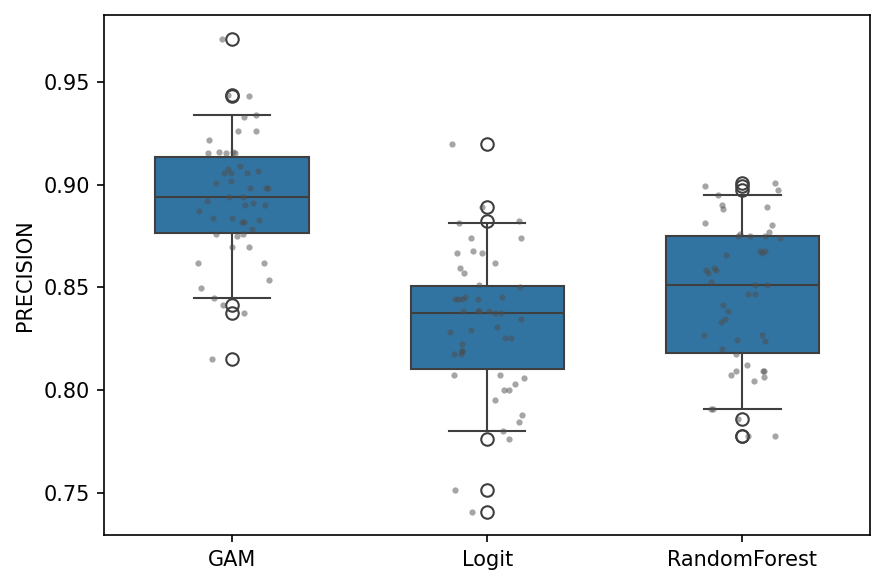

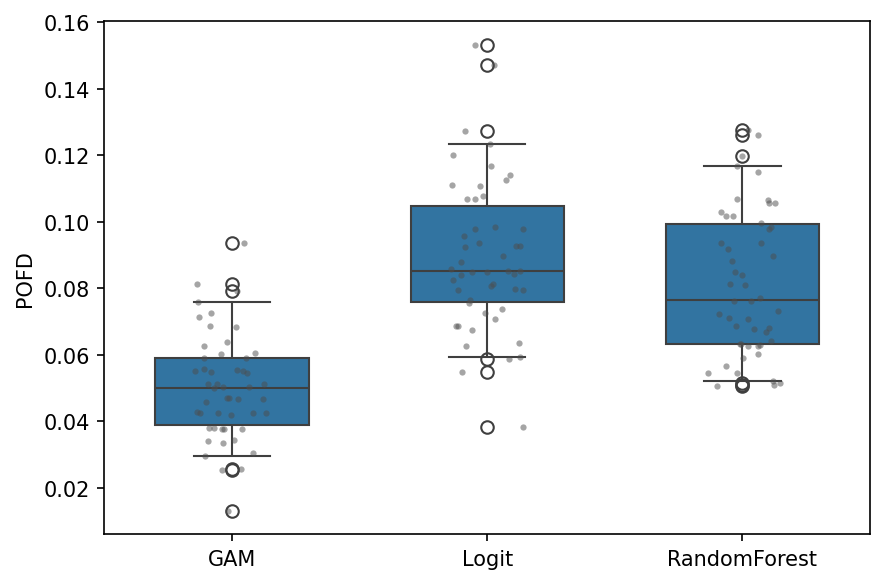

In [9]:
# =========================
# 2) BOXPLOTS por métrica (modelo en x)
# =========================
# out_fig_dir = "/home/oisanchezp/Thesis/figuras"
# os.makedirs(out_fig_dir, exist_ok=True)

for m in metrics:
    plt.figure(figsize=(6, 4), dpi=150)

    sns.boxplot(
        data=df,
        x="modelo",
        y=m,
        whis=(5, 95),
        width=0.6
    )

    sns.stripplot(
        data=df,
        x="modelo",
        y=m,
        color="0.3",
        alpha=0.5,
        jitter=0.15,
        size=3
    )

    plt.ylabel(m.upper())
    plt.xlabel("")
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_boxplot_modelos.png")
    #plt.savefig(out_png, dpi=300)
    plt.show()

    #print(f"Figura guardada: {out_png}")


=== Métrica: AUC ===


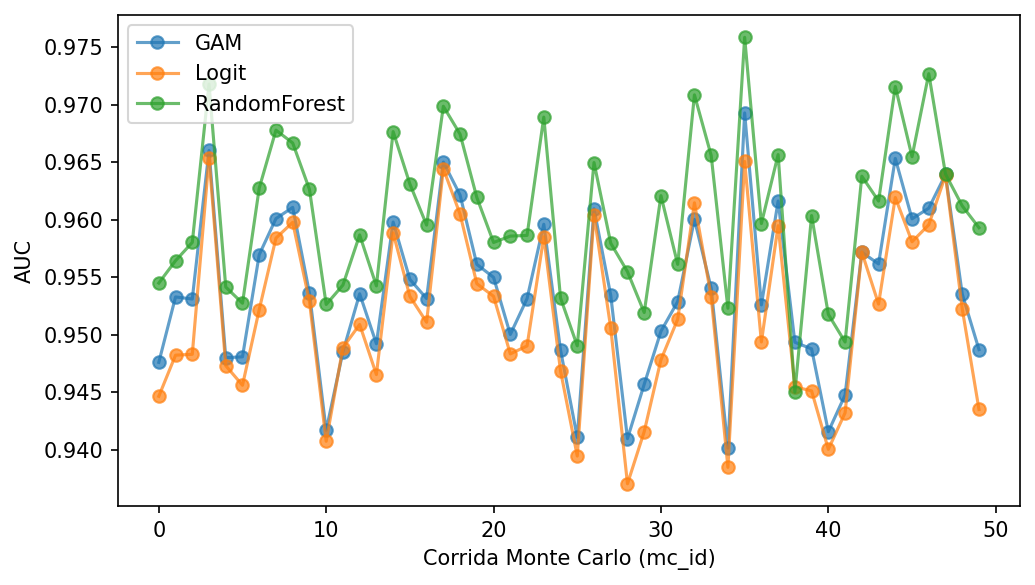


=== Métrica: F1 ===


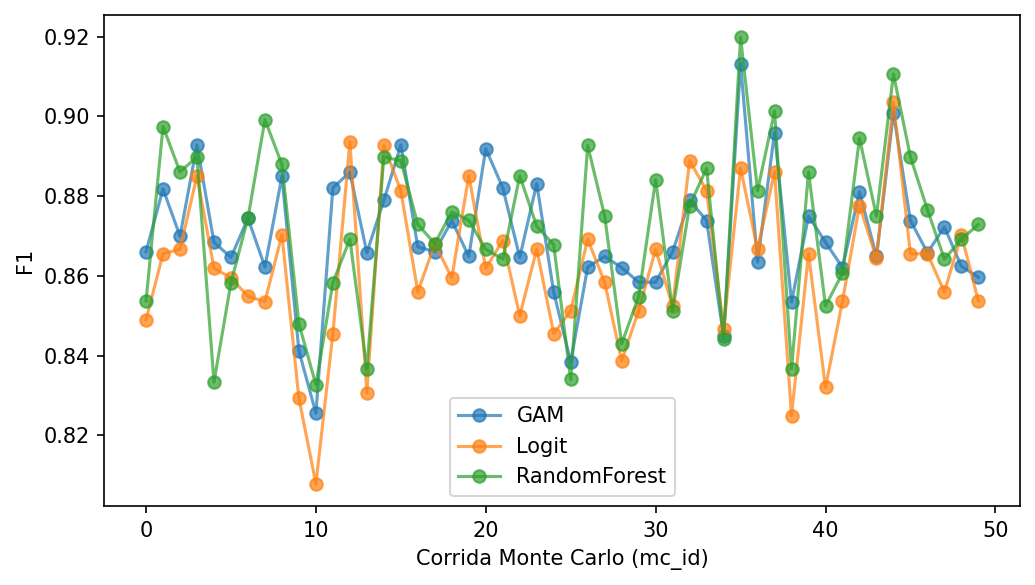


=== Métrica: RECALL ===


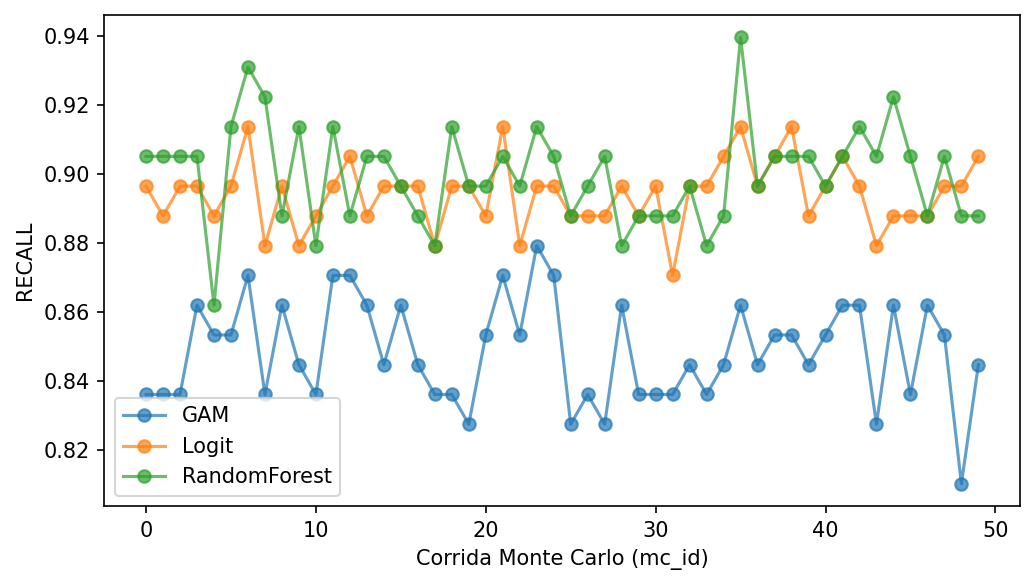


=== Métrica: PRECISION ===


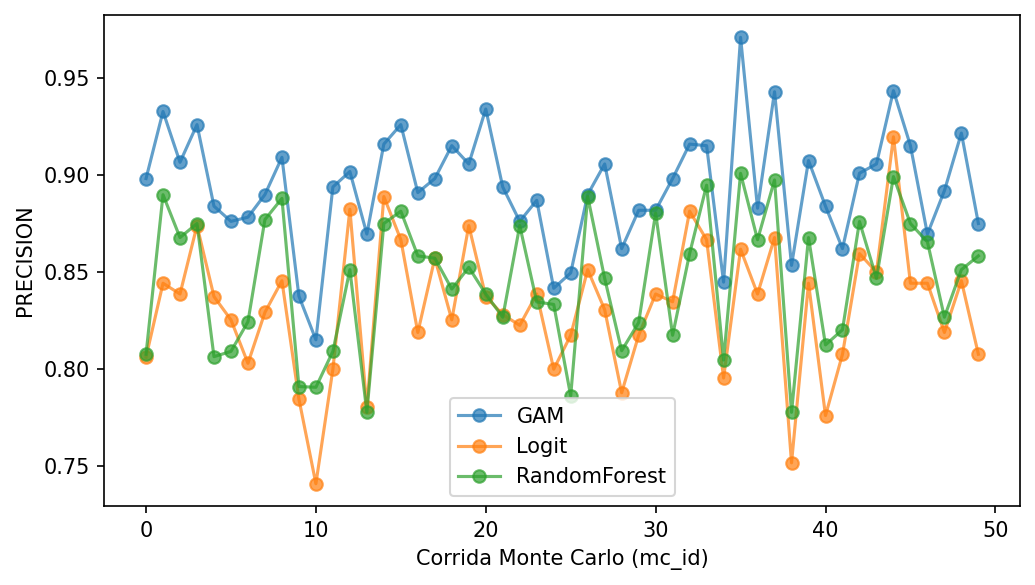


=== Métrica: POFD ===


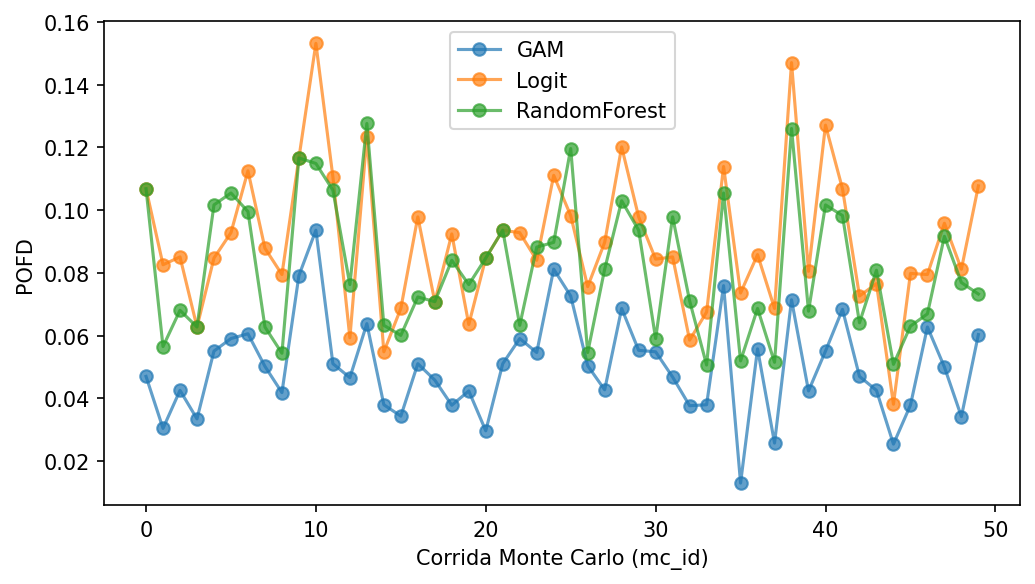

In [10]:
# =========================
# 3) LÍNEAS por métrica (x=mc_id, y=m, color=modelo)
# =========================
for m in metrics:
    pivot = df.pivot(index="mc_id", columns="modelo", values=m).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(m.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{m}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Métrica: {m.upper()} ===")
    plt.show()

    #print(f"Figura guardada: {out_png}")


=== Conteo: TP ===


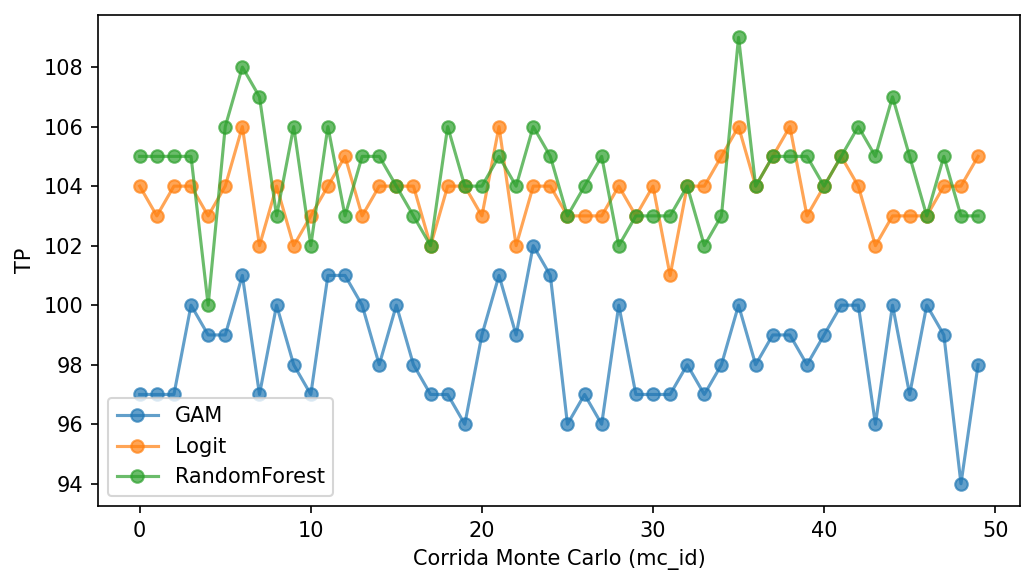


=== Conteo: TN ===


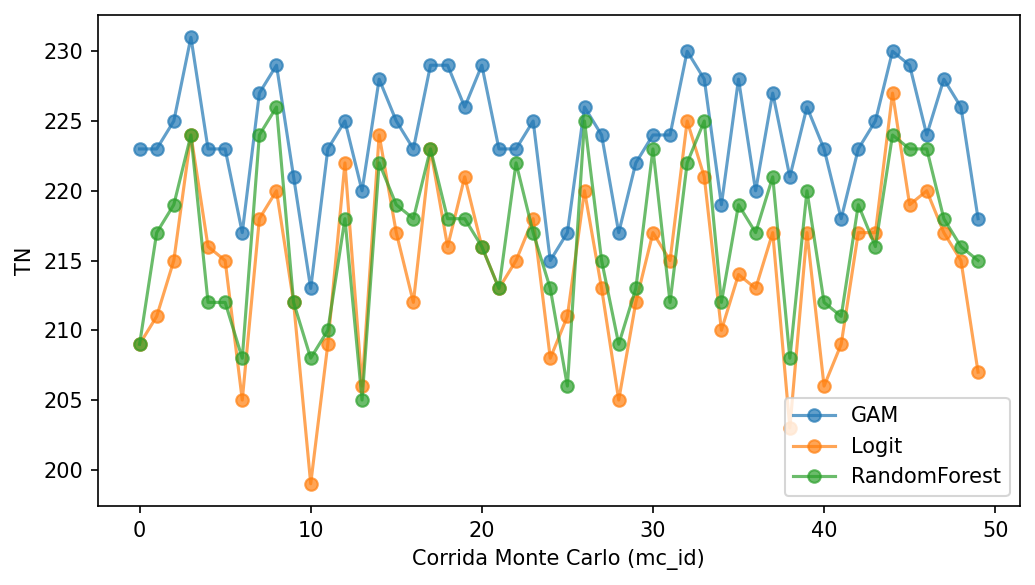


=== Conteo: FP ===


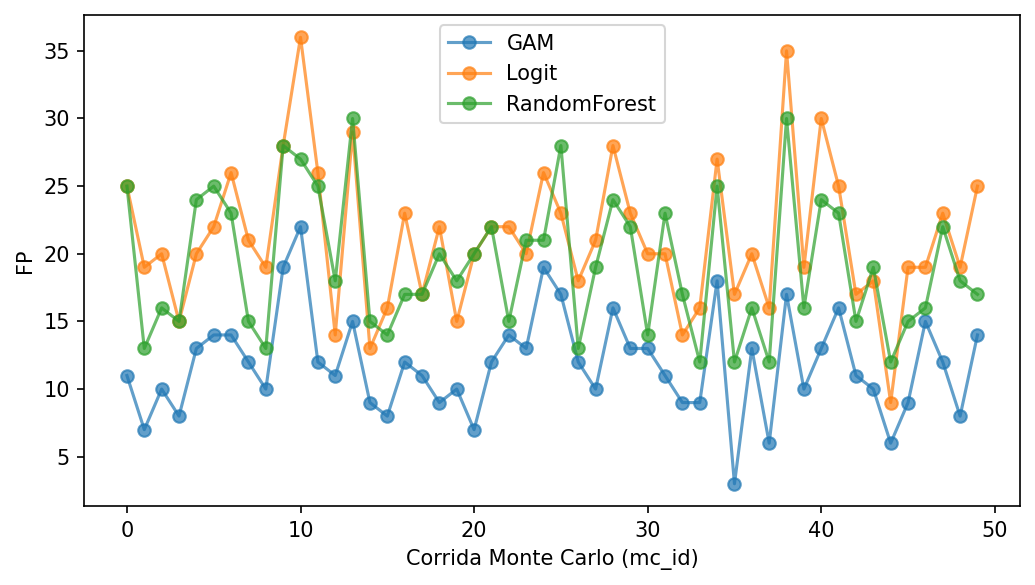


=== Conteo: FN ===


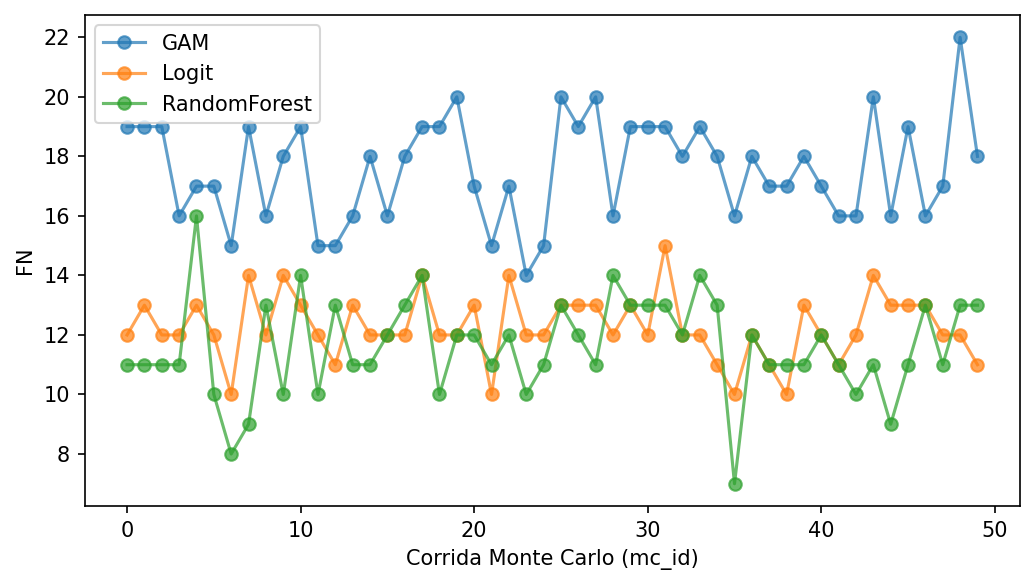

In [11]:
# =========================
# 4) TP/TN/FP/FN: líneas por corrida, 1 figura por variable
#    (x=mc_id, y=conteo, color=modelo)
# =========================
for c in count_cols:
    pivot_c = df.pivot(index="mc_id", columns="modelo", values=c).sort_index()

    plt.figure(figsize=(7, 4), dpi=150)

    for modelo in pivot_c.columns:
        plt.plot(
            pivot_c.index,
            pivot_c[modelo],
            marker="o",
            linestyle="-",
            alpha=0.7,
            label=modelo
        )

    plt.xlabel("Corrida Monte Carlo (mc_id)")
    plt.ylabel(c.upper())
    plt.legend()
    plt.tight_layout()

    #out_png = os.path.join(out_fig_dir, f"{c}_lineas_por_mc.png")
    #plt.savefig(out_png, dpi=300)
    print(f"\n=== Conteo: {c.upper()} ===")
    plt.show()

    #print(f"Figura guardada: {out_png}")